# Blood Cell Classification — End-to-End Notebook

This notebook is a thin driver for the same Python pipeline in `src/`. Running the cells calls the same functions as:

`crop_dataset.py` → `deduplicate_processed_dataset.py` → `train.py` → `evaluate.py` → `plot_model_results.py` → `gradcam.py` → `predict.py`

Set the flags in the setup cell before **Run All**. Training three backbones from scratch can take a long time; leave `SKIP_TRAIN_IF_CHECKPOINT = True` to reuse existing `outputs/checkpoints/best_*.pt` files.


## 1. Setup and configuration

The setup cell clones your GitHub repository, mounts Google Drive in Colab, and copies the dataset from either `My Drive/blood-cell-classification/data` or `My Drive/data`. The Drive folder should contain `raw/` and/or `processed/`. It then uses the GPU when available and loads the project configuration.

In [10]:
from pathlib import Path
import os
import shutil
import subprocess
import sys

from IPython.display import Image, display


REPO_URL = "https://github.com/Sushey01/DeepLearning.git"
COLAB_REPO_DIR = Path("/content/blood-cell-classification")
IN_COLAB = "google.colab" in sys.modules


def find_project_root() -> Path | None:
    starts = [Path.cwd(), COLAB_REPO_DIR, Path("/content")]
    candidates = []
    for start in starts:
        start = start.resolve()
        candidates.extend([start, *start.parents])
    for candidate in dict.fromkeys(candidates):
        if (candidate / "configs" / "config.yaml").exists() and (candidate / "src" / "train.py").exists():
            return candidate
    return None


def copy_drive_data(project_root: Path) -> None:
    if not IN_COLAB:
        return

    from google.colab import drive
    drive.mount("/content/drive")

    drive_data_candidates = [
        Path("/content/drive/MyDrive/blood-cell-classification/data"),
        Path("/content/drive/MyDrive/data"),
    ]
    drive_data = next((path for path in drive_data_candidates if path.exists()), None)
    if drive_data is None:
        raise FileNotFoundError(
            "Dataset folder not found in Google Drive. Put it in "
            "My Drive/blood-cell-classification/data or My Drive/data."
        )

    destination = project_root / "data"
    destination.mkdir(parents=True, exist_ok=True)
    for name in ("raw", "processed"):
        source = drive_data / name
        target = destination / name
        if source.exists() and not target.exists():
            print(f"Copying {source} to {target} ...")
            shutil.copytree(source, target)
    print("Drive data location:", drive_data)


PROJECT_ROOT = find_project_root()
if PROJECT_ROOT is None and Path("/content").exists():
    print(f"Project not found. Cloning {REPO_URL} ...")
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(COLAB_REPO_DIR)], check=True)
    PROJECT_ROOT = find_project_root()

if PROJECT_ROOT is None:
    raise FileNotFoundError("Project not found. Upload or clone it under /content first.")

copy_drive_data(PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    print("Using the existing local Python environment; skipping package installation.")

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

CONFIG_PATH = "configs/config.yaml"

RUN_DEDUP = False
SKIP_TRAIN_IF_CHECKPOINT = True
TRAIN_MODELS = ["efficientnet_b0"]

import crop_dataset
import evaluate
import plot_model_results
import train
import gradcam
import predict
from utils import count_images_per_class, get_device, load_config, set_seed

cfg = load_config(CONFIG_PATH)
set_seed(cfg.get("seed", 42))
DEVICE = get_device()
processed_dir = PROJECT_ROOT / cfg["processed_dir"]
raw_dir = PROJECT_ROOT / cfg["raw_images_dir"]
labels_dir = PROJECT_ROOT / cfg["raw_labels_dir"]
RUN_CROP = not processed_dir.exists()
if RUN_CROP and (not raw_dir.exists() or not labels_dir.exists()):
    raise FileNotFoundError(
        "No processed dataset or raw dataset was found. Put raw images and labels "
        "in Google Drive under the expected data/raw folders."
    )

print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)
print("Classes:", cfg["classes"])
print("Models:", TRAIN_MODELS)
print("RUN_CROP:", RUN_CROP, "RUN_DEDUP:", RUN_DEDUP)

if DEVICE.type != "cuda":
    print("Warning: Colab GPU is not enabled; training will run on CPU.")

Using the existing local Python environment; skipping package installation.
Project root: C:\Users\MSI\Shekhar\DeepLearning
Device: cuda
Classes: ['WBC', 'RBC', 'Platelet']
Models: ['efficientnet_b0']
RUN_CROP: False RUN_DEDUP: False


## 2. Crop the raw dataset into processed cell images

Calls `crop_dataset.main`, the same entry point as `python src/crop_dataset.py --config configs/config.yaml`. This writes crops under `data/processed/<split>/<class>/`. Re-run this when the processed set is incomplete (the current folder on disk may be far smaller than the full TXL-PBC crop set).


In [11]:
if RUN_CROP:
    crop_dataset.main(CONFIG_PATH)
else:
    print("Skipping crop. Use an existing data/processed directory for the quick run.")

Skipping crop. Use an existing data/processed directory for the quick run.


## 3. Inspect the generated dataset

Counts PNG crops per split and class using `utils.count_images_per_class`.


In [12]:
processed = Path(cfg["processed_dir"])
for split in ("train", "val", "test"):
    counts = count_images_per_class(str(processed / split), cfg["classes"])
    total = sum(counts.values())
    print(f"{split:5s}  {counts}  total={total}")


train  {'WBC': 901, 'RBC': 10854, 'Platelet': 382}  total=12137
val    {'WBC': 252, 'RBC': 3180, 'Platelet': 112}  total=3544
test   {'WBC': 127, 'RBC': 1593, 'Platelet': 48}  total=1768


## 4. Near-duplicate audit

Calls `deduplicate_processed_dataset.deduplicate_processed_dataset`. A dry run always runs (same as `python src/deduplicate_processed_dataset.py`). Setting `APPLY_DEDUP = True` **deletes** near-duplicate crops (`--apply`). Leave it False unless you intend to clean the processed dataset.


In [13]:
if RUN_DEDUP:
    import deduplicate_processed_dataset
    deduplicate_processed_dataset.deduplicate_processed_dataset(apply_cleanup=False)
else:
    print("Skipping duplicate audit. Set RUN_DEDUP=True only when needed.")

Skipping duplicate audit. Set RUN_DEDUP=True only when needed.


## 5. Train models

Calls `train.main` for each name in `TRAIN_MODELS` — the same function as `python src/train.py --config configs/config.yaml --model <name>`. This uses weighted loss, early stopping, CSV logs, and `outputs/checkpoints/best_<model>.pt`.

If `SKIP_TRAIN_IF_CHECKPOINT` is True and a checkpoint already exists, that model is skipped.


In [14]:
checkpoints_dir = Path(cfg["checkpoints_dir"])
for model_name in TRAIN_MODELS:
    ckpt = checkpoints_dir / f"best_{model_name}.pt"
    if SKIP_TRAIN_IF_CHECKPOINT and ckpt.exists():
        print(f"Skipping train for {model_name} (found {ckpt}). Set SKIP_TRAIN_IF_CHECKPOINT=False to retrain.")
        continue
    train.main(CONFIG_PATH, model_name)


Skipping train for efficientnet_b0 (found outputs\checkpoints\best_efficientnet_b0.pt). Set SKIP_TRAIN_IF_CHECKPOINT=False to retrain.


## 6. Evaluate on the held-out test set

Evaluates each model listed in `TRAIN_MODELS` on the test set. By default this is only EfficientNet-B0, matching the lightweight training run. Add more models to `TRAIN_MODELS` if you want a comparison.

In [15]:
for model_name in TRAIN_MODELS:
    evaluate.main(CONFIG_PATH, model_name)

C:\Users\MSI\Shekhar\DeepLearning\src\evaluate.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=device))


              precision    recall  f1-score   support

         WBC       1.00      1.00      1.00       127
         RBC       1.00      1.00      1.00      1593
    Platelet       1.00      1.00      1.00        48

    accuracy                           1.00      1768
   macro avg       1.00      1.00      1.00      1768
weighted avg       1.00      1.00      1.00      1768


Model comparison summary
Model                   Macro-F1  Macro-AUC  Accuracy  Params(M) Training Time  Peak GPU Memory
efficientnet_b0              1.0        1.0       1.0   4.011391 640.4930837154388  2833.5458984375

Saved comparison table to outputs\results\comparison_table.json


## 7. Loss curves and saved figures

Calls `plot_model_results.plot_loss_curves` (`python src/plot_model_results.py`). Figures are written with the Agg backend, so they are displayed from disk here.


Saved loss-curve plot to outputs\results\loss_curves.png
outputs\results\loss_curves.png


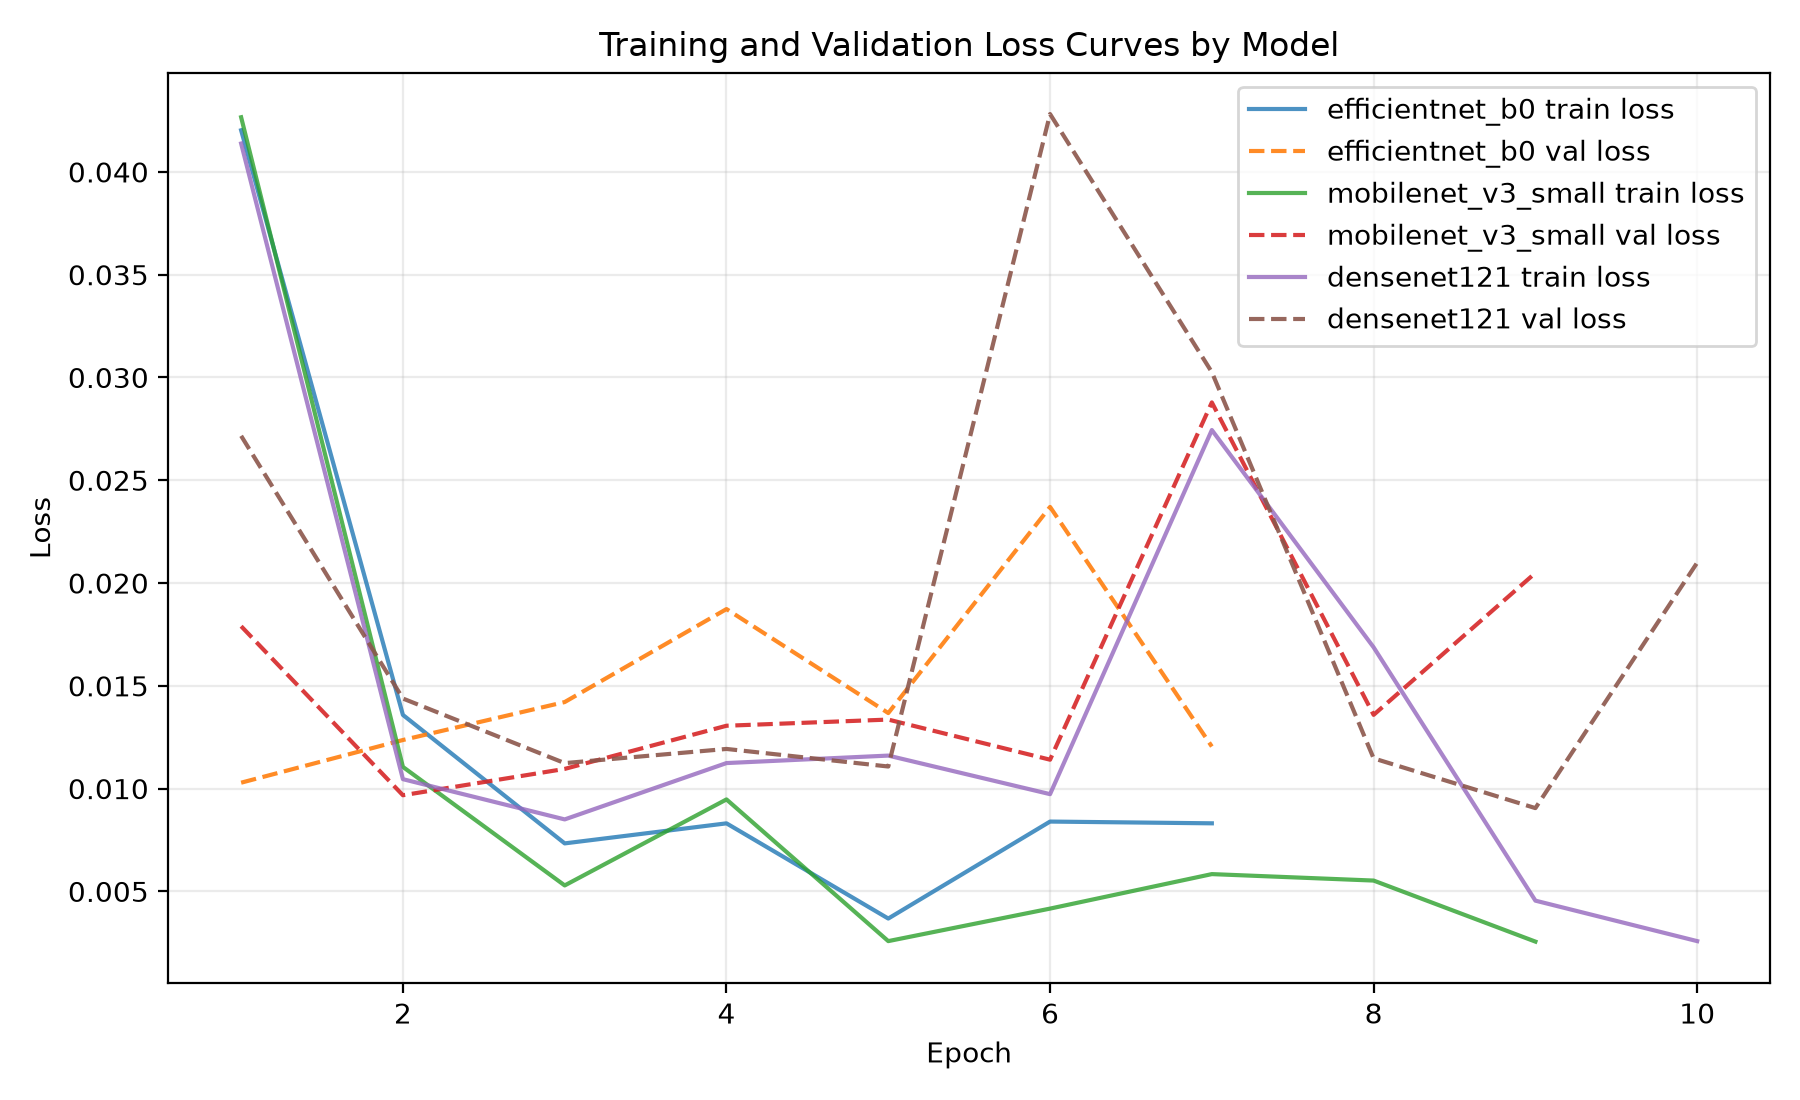

outputs\results\confusion_matrices_all.png


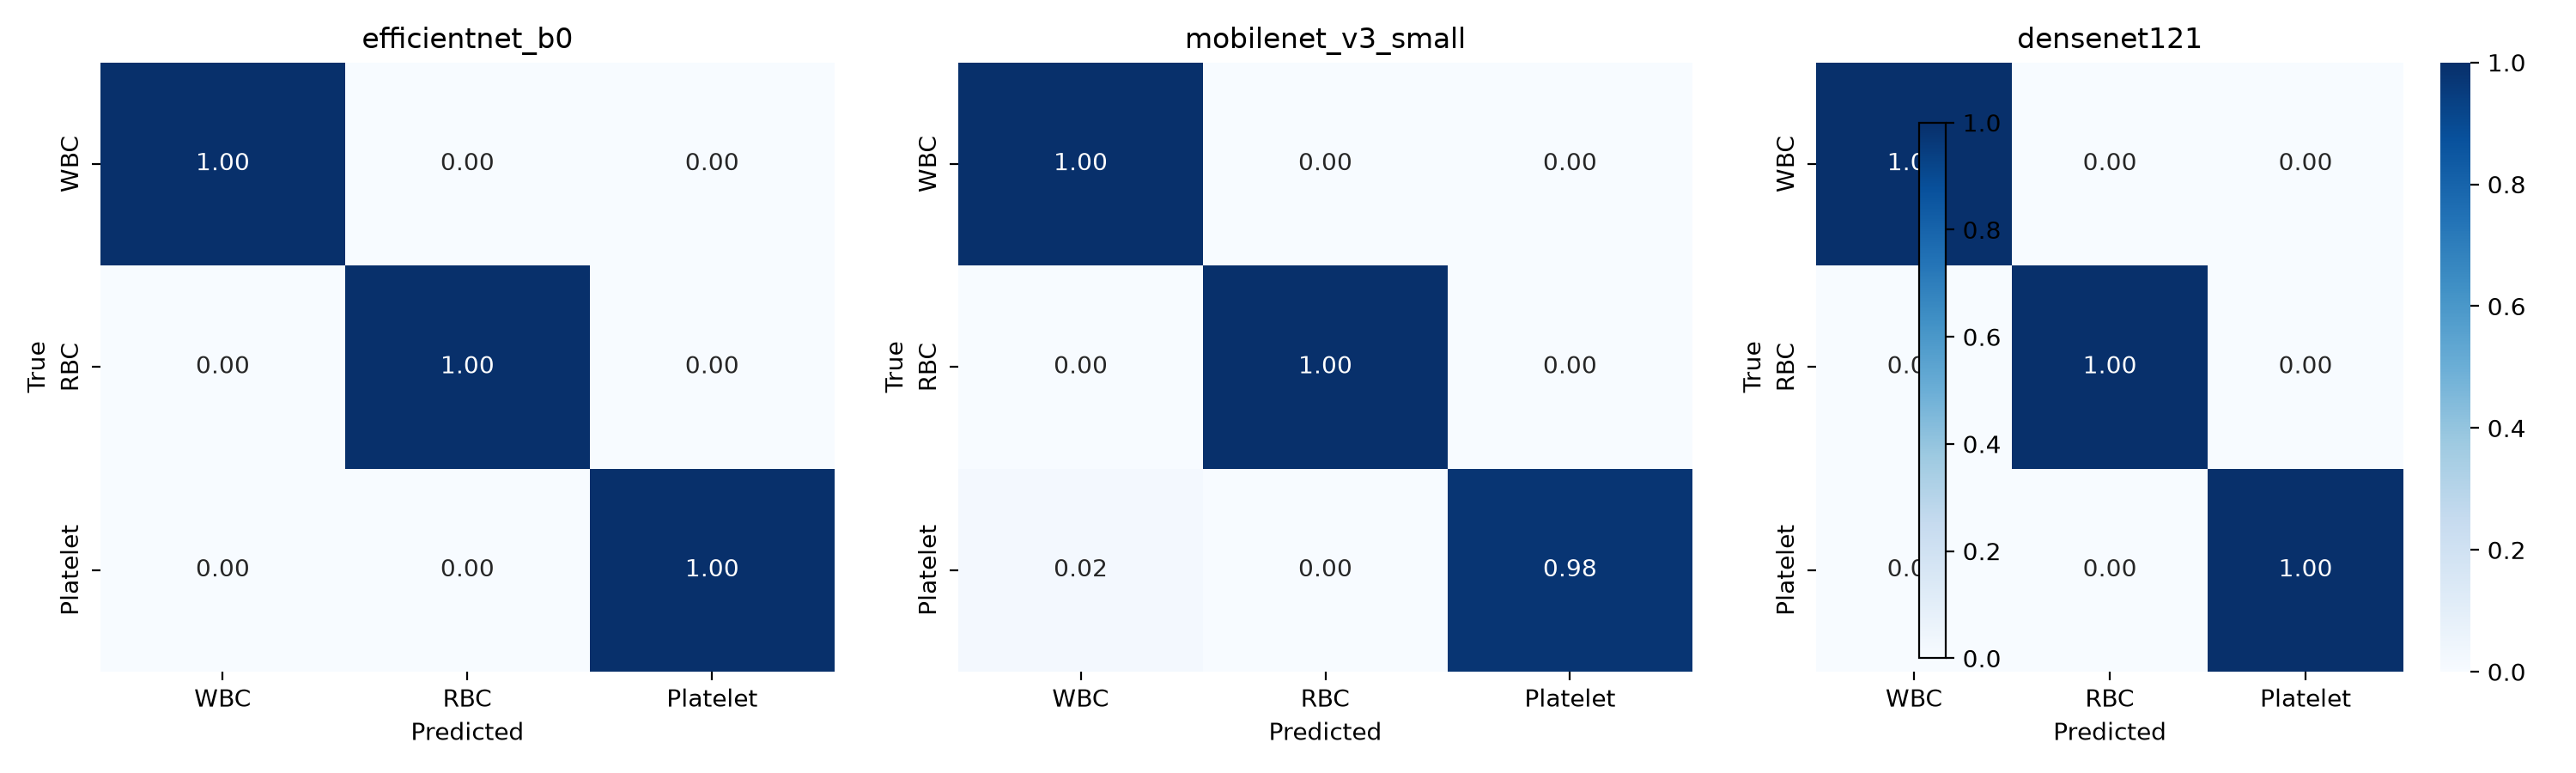

In [16]:
plot_model_results.plot_loss_curves(CONFIG_PATH)

results_dir = Path(cfg["results_dir"])
for name in ("loss_curves.png", "confusion_matrices_all.png"):
    path = results_dir / name
    if path.exists():
        print(path)
        display(Image(filename=str(path)))
    else:
        print(f"Not found (run evaluate with multiple models / plot after training): {path}")


## 8. Grad-CAM

Calls `gradcam.run_gradcam` for EfficientNet-B0 (same as `python src/gradcam.py --config configs/config.yaml --model efficientnet_b0`).


In [17]:
RUN_GRADCAM = False

gradcam_model = "efficientnet_b0"
ckpt = Path(cfg["checkpoints_dir"]) / f"best_{gradcam_model}.pt"
if not RUN_GRADCAM:
    print("Skipping Grad-CAM. Set RUN_GRADCAM=True after evaluation if needed.")
elif not ckpt.exists():
    print(f"Skipping Grad-CAM: missing {ckpt}")
else:
    gradcam.run_gradcam(CONFIG_PATH, gradcam_model)
    for cls_name in cfg["classes"]:
        path = Path(cfg["results_dir"]) / f"gradcam_{cls_name}_correct.png"
        if path.exists():
            print(path)
            display(Image(filename=str(path)))

Skipping Grad-CAM. Set RUN_GRADCAM=True after evaluation if needed.


## 9. Single-image prediction

Uses `predict.load_model` and `predict.predict_image`, the same inference path as `python src/predict.py --image ...`.


Image: data\processed\test\WBC\00552f60c43350a0bf516cfbc13db058_9.png
Predicted class: WBC
Confidence: 0.9999
Probabilities: {'WBC': 0.9999, 'RBC': 0.0, 'Platelet': 0.0}


C:\Users\MSI\Shekhar\DeepLearning\src\predict.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=device))


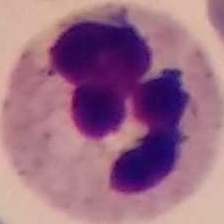

In [18]:
predict_model = "efficientnet_b0"
ckpt = Path(cfg["checkpoints_dir"]) / f"best_{predict_model}.pt"
sample_dir = Path(cfg["processed_dir"]) / "test"
sample = None
for cls_name in cfg["classes"]:
    files = sorted((sample_dir / cls_name).glob("*.png"))
    if files:
        sample = files[0]
        break

if not ckpt.exists():
    print(f"Skipping predict: missing {ckpt}")
elif sample is None:
    print(f"Skipping predict: no test PNGs under {sample_dir}")
else:
    model, classes, pred_cfg, device = predict.load_model(predict_model, CONFIG_PATH)
    result = predict.predict_image(str(sample), model, classes, pred_cfg, device)
    print("Image:", sample)
    print("Predicted class:", result["predicted_class"])
    print("Confidence:", round(result["confidence"], 4))
    print("Probabilities:", {k: round(v, 4) for k, v in result["probabilities"].items()})
    display(Image(filename=str(sample)))


## Interpretation

- Training, evaluation, Grad-CAM, and prediction all go through `src/`, so notebook results should match CLI runs with the same config, data, and checkpoints.
- `SKIP_TRAIN_IF_CHECKPOINT=True` reuses existing weights; set it to False for a from-scratch run equivalent to calling `train.py` for each backbone.
- `APPLY_DEDUP=True` changes `data/processed` permanently. Dry-run output is written under `outputs/results/` (deduplication summary).
- Current `data/processed` may be incomplete until crop (and optional dedup apply) is run; counts in the inspect cell should be checked before interpreting metrics.


## Conclusion

This notebook does not reimplement the models or training loop. It only locates the repo, loads the shared config, and calls the project scripts so anyone running it follows the same pipeline as the Python files.
